In [2]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

os.makedirs("images", exist_ok=True)

In [5]:
from zipfile import ZipFile

with ZipFile("/content/Project11_Multi-stage continuous-flow manufacturing process.zip", "r") as zip_ref:
    zip_ref.extractall("/content/")

In [6]:
import os

print(os.listdir("/content"))

['.config', 'Project11_Multi-stage continuous-flow manufacturing process.zip', 'Project11', 'images', 'sample_data']


In [7]:
import os

print(os.listdir("/content/Project11"))

['Project11_Multi-stage continuous-flow manufacturing process.docx', 'Project11_Multi-stage continuous-flow manufacturing process.zip']


In [9]:
import os

print(os.listdir("/content/Project11"))

['Project11_Multi-stage continuous-flow manufacturing process.docx', 'Project11_Multi-stage continuous-flow manufacturing process.zip']


In [10]:
import os

for root, dirs, files in os.walk("/content/Project11"):
    for file in files:
        print(os.path.join(root, file))

/content/Project11/Project11_Multi-stage continuous-flow manufacturing process.docx
/content/Project11/Project11_Multi-stage continuous-flow manufacturing process.zip


In [11]:
from zipfile import ZipFile

with ZipFile("/content/Project11/Project11_Multi-stage continuous-flow manufacturing process.zip", "r") as zip_ref:
    zip_ref.extractall("/content/Project11")

In [12]:
import os

for root, dirs, files in os.walk("/content/Project11"):
    for file in files:
        print(os.path.join(root, file))

/content/Project11/notes_on_dataset.txt
/content/Project11/Project11_Multi-stage continuous-flow manufacturing process.docx
/content/Project11/Project11_Multi-stage continuous-flow manufacturing process.zip
/content/Project11/continuous_factory_process.csv


In [13]:
import pandas as pd

df = pd.read_csv("/content/Project11/continuous_factory_process.csv")

df.head()

,time_stamp,AmbientConditions.AmbientHumidity.U.Actual,AmbientConditions.AmbientTemperature.U.Actual,Machine1.RawMaterial.Property1,Machine1.RawMaterial.Property2,Machine1.RawMaterial.Property3,Machine1.RawMaterial.Property4,Machine1.RawMaterialFeederParameter.U.Actual,Machine1.Zone1Temperature.C.Actual,Machine1.Zone2Temperature.C.Actual,...,Stage2.Output.Measurement10.U.Actual,Stage2.Output.Measurement10.U.Setpoint,Stage2.Output.Measurement11.U.Actual,Stage2.Output.Measurement11.U.Setpoint,Stage2.Output.Measurement12.U.Actual,Stage2.Output.Measurement12.U.Setpoint,Stage2.Output.Measurement13.U.Actual,Stage2.Output.Measurement13.U.Setpoint,Stage2.Output.Measurement14.U.Actual,Stage2.Output.Measurement14.U.Setpoint
0,2019-03-06 10:52:33,17.24,23.53,11.54,200,963.0,247,1241.26,72.0,72.3,...,0.0,7.93,0.0,5.65,0.0,1.85,0.0,2.89,0.0,11.71
1,2019-03-06 10:52:34,17.24,23.53,11.54,200,963.0,247,1246.09,72.0,72.3,...,0.0,7.93,0.0,5.65,0.0,1.85,0.0,2.89,0.0,11.71
2,2019-03-06 10:52:35,17.24,23.53,11.54,200,963.0,247,1246.29,72.0,72.3,...,0.0,7.93,0.0,5.65,0.0,1.85,0.0,2.89,0.0,11.71
3,2019-03-06 10:52:36,17.24,23.53,11.54,200,963.0,247,1247.59,72.0,72.3,...,0.0,7.93,0.0,5.65,0.0,1.85,0.0,2.89,0.0,11.71
4,2019-03-06 10:52:37,17.24,23.53,11.54,200,963.0,247,1252.83,72.1,72.4,...,0.0,7.93,0.0,5.65,0.0,1.85,0.0,2.89,0.0,11.71


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14088 entries, 0 to 14087
Columns: 116 entries, time_stamp to Stage2.Output.Measurement14.U.Setpoint
dtypes: float64(108), int64(7), object(1)
memory usage: 12.5+ MB


In [15]:
df.columns

Index(['time_stamp', 'AmbientConditions.AmbientHumidity.U.Actual',
       'AmbientConditions.AmbientTemperature.U.Actual',
       'Machine1.RawMaterial.Property1', 'Machine1.RawMaterial.Property2',
       'Machine1.RawMaterial.Property3', 'Machine1.RawMaterial.Property4',
       'Machine1.RawMaterialFeederParameter.U.Actual',
       'Machine1.Zone1Temperature.C.Actual',
       'Machine1.Zone2Temperature.C.Actual',
       ...
       'Stage2.Output.Measurement10.U.Actual',
       'Stage2.Output.Measurement10.U.Setpoint',
       'Stage2.Output.Measurement11.U.Actual',
       'Stage2.Output.Measurement11.U.Setpoint',
       'Stage2.Output.Measurement12.U.Actual',
       'Stage2.Output.Measurement12.U.Setpoint',
       'Stage2.Output.Measurement13.U.Actual',
       'Stage2.Output.Measurement13.U.Setpoint',
       'Stage2.Output.Measurement14.U.Actual',
       'Stage2.Output.Measurement14.U.Setpoint'],
      dtype='object', length=116)

In [16]:
df.head()

,time_stamp,AmbientConditions.AmbientHumidity.U.Actual,AmbientConditions.AmbientTemperature.U.Actual,Machine1.RawMaterial.Property1,Machine1.RawMaterial.Property2,Machine1.RawMaterial.Property3,Machine1.RawMaterial.Property4,Machine1.RawMaterialFeederParameter.U.Actual,Machine1.Zone1Temperature.C.Actual,Machine1.Zone2Temperature.C.Actual,...,Stage2.Output.Measurement10.U.Actual,Stage2.Output.Measurement10.U.Setpoint,Stage2.Output.Measurement11.U.Actual,Stage2.Output.Measurement11.U.Setpoint,Stage2.Output.Measurement12.U.Actual,Stage2.Output.Measurement12.U.Setpoint,Stage2.Output.Measurement13.U.Actual,Stage2.Output.Measurement13.U.Setpoint,Stage2.Output.Measurement14.U.Actual,Stage2.Output.Measurement14.U.Setpoint
0,2019-03-06 10:52:33,17.24,23.53,11.54,200,963.0,247,1241.26,72.0,72.3,...,0.0,7.93,0.0,5.65,0.0,1.85,0.0,2.89,0.0,11.71
1,2019-03-06 10:52:34,17.24,23.53,11.54,200,963.0,247,1246.09,72.0,72.3,...,0.0,7.93,0.0,5.65,0.0,1.85,0.0,2.89,0.0,11.71
2,2019-03-06 10:52:35,17.24,23.53,11.54,200,963.0,247,1246.29,72.0,72.3,...,0.0,7.93,0.0,5.65,0.0,1.85,0.0,2.89,0.0,11.71
3,2019-03-06 10:52:36,17.24,23.53,11.54,200,963.0,247,1247.59,72.0,72.3,...,0.0,7.93,0.0,5.65,0.0,1.85,0.0,2.89,0.0,11.71
4,2019-03-06 10:52:37,17.24,23.53,11.54,200,963.0,247,1252.83,72.1,72.4,...,0.0,7.93,0.0,5.65,0.0,1.85,0.0,2.89,0.0,11.71


In [17]:
df.shape

(14088, 116)

In [18]:
print(df.columns.tolist())

['time_stamp', 'AmbientConditions.AmbientHumidity.U.Actual', 'AmbientConditions.AmbientTemperature.U.Actual', 'Machine1.RawMaterial.Property1', 'Machine1.RawMaterial.Property2', 'Machine1.RawMaterial.Property3', 'Machine1.RawMaterial.Property4', 'Machine1.RawMaterialFeederParameter.U.Actual', 'Machine1.Zone1Temperature.C.Actual', 'Machine1.Zone2Temperature.C.Actual', 'Machine1.MotorAmperage.U.Actual', 'Machine1.MotorRPM.C.Actual', 'Machine1.MaterialPressure.U.Actual', 'Machine1.MaterialTemperature.U.Actual', 'Machine1.ExitZoneTemperature.C.Actual', 'Machine2.RawMaterial.Property1', 'Machine2.RawMaterial.Property2', 'Machine2.RawMaterial.Property3', 'Machine2.RawMaterial.Property4', 'Machine2.RawMaterialFeederParameter.U.Actual', 'Machine2.Zone1Temperature.C.Actual', 'Machine2.Zone2Temperature.C.Actual', 'Machine2.MotorAmperage.U.Actual', 'Machine2.MotorRPM.C.Actual', 'Machine2.MaterialPressure.U.Actual', 'Machine2.MaterialTemperature.U.Actual', 'Machine2.ExitZoneTemperature.C.Actual', 

In [19]:
df["time_stamp"] = pd.to_datetime(df["time_stamp"])

df["Year"] = df["time_stamp"].dt.year
df["Month"] = df["time_stamp"].dt.month
df["Day"] = df["time_stamp"].dt.day
df["Hour"] = df["time_stamp"].dt.hour
df["Minute"] = df["time_stamp"].dt.minute

df.drop("time_stamp", axis=1, inplace=True)

In [20]:
target_cols = [col for col in df.columns
               if "Stage2.Output.Measurement" in col
               and ".Actual" in col]

print(target_cols)
print("Total Targets:", len(target_cols))

['Stage2.Output.Measurement0.U.Actual', 'Stage2.Output.Measurement1.U.Actual', 'Stage2.Output.Measurement2.U.Actual', 'Stage2.Output.Measurement3.U.Actual', 'Stage2.Output.Measurement4.U.Actual', 'Stage2.Output.Measurement5.U.Actual', 'Stage2.Output.Measurement6.U.Actual', 'Stage2.Output.Measurement7.U.Actual', 'Stage2.Output.Measurement8.U.Actual', 'Stage2.Output.Measurement9.U.Actual', 'Stage2.Output.Measurement10.U.Actual', 'Stage2.Output.Measurement11.U.Actual', 'Stage2.Output.Measurement12.U.Actual', 'Stage2.Output.Measurement13.U.Actual', 'Stage2.Output.Measurement14.U.Actual']
Total Targets: 15


In [21]:
X = df.drop(columns=target_cols)
y = df[target_cols]

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [23]:
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor

model = MultiOutputRegressor(
    RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )
)

model.fit(X_train, y_train)

MultiOutputRegressor(estimator=RandomForestRegressor(n_jobs=-1,
                                                     random_state=42))

In [24]:
y_pred = model.predict(X_test)

In [25]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:.4f}")
print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2 Score: {r2:.4f}")

MAE : 0.4224
MSE : 3.3203
RMSE: 1.8222
R2 Score: 0.7399


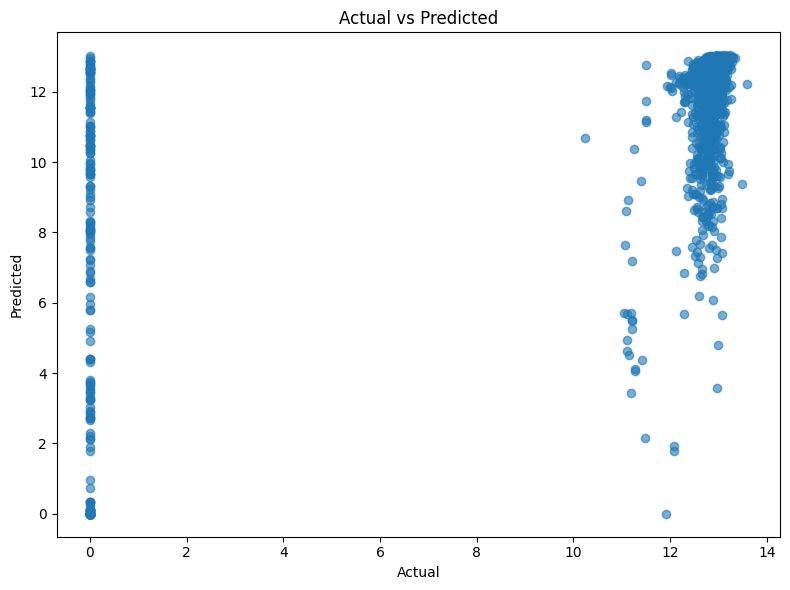

In [26]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test.iloc[:,0],
    y_pred[:,0],
    alpha=0.6
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")

plt.tight_layout()
plt.savefig("images/actual_vs_predicted.png")
plt.show()

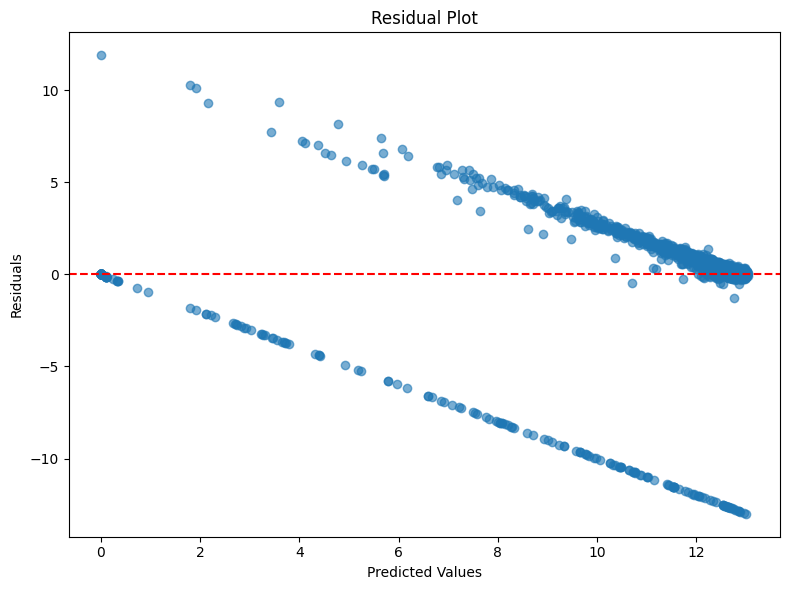

In [27]:
residuals = y_test.iloc[:, 0] - y_pred[:, 0]

plt.figure(figsize=(8,6))
plt.scatter(y_pred[:, 0], residuals, alpha=0.6)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.tight_layout()
plt.savefig("images/residual_plot.png")
plt.show()

In [28]:
feature_importance = model.estimators_[0].feature_importances_

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": feature_importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df.head(15))

                                              Feature  Importance
80                     Machine5.Temperature3.C.Actual    0.399774
24              Machine2.MaterialTemperature.U.Actual    0.041235
81                     Machine5.Temperature4.C.Actual    0.037458
36              Machine3.MaterialTemperature.U.Actual    0.026859
33                    Machine3.MotorAmperage.U.Actual    0.023234
6        Machine1.RawMaterialFeederParameter.U.Actual    0.022499
18       Machine2.RawMaterialFeederParameter.U.Actual    0.021585
11                 Machine1.MaterialPressure.U.Actual    0.021485
35                 Machine3.MaterialPressure.U.Actual    0.018089
84                  Machine5.ExitTemperature.U.Actual    0.016993
23                 Machine2.MaterialPressure.U.Actual    0.016722
30       Machine3.RawMaterialFeederParameter.U.Actual    0.015658
34                         Machine3.MotorRPM.C.Actual    0.015568
69               Stage1.Output.Measurement14.U.Actual    0.015025
39  FirstS

<Figure size 1000x800 with 0 Axes>

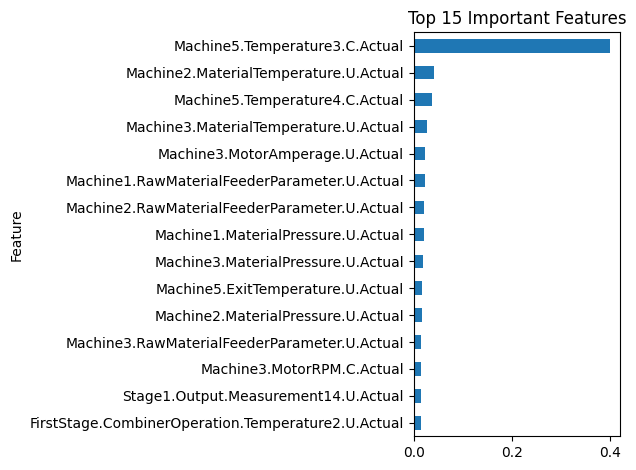

In [29]:
plt.figure(figsize=(10,8))

importance_df.head(15).sort_values("Importance").plot(
    x="Feature",
    y="Importance",
    kind="barh",
    legend=False
)

plt.title("Top 15 Important Features")

plt.tight_layout()

plt.savefig("images/feature_importance.png")
plt.show()

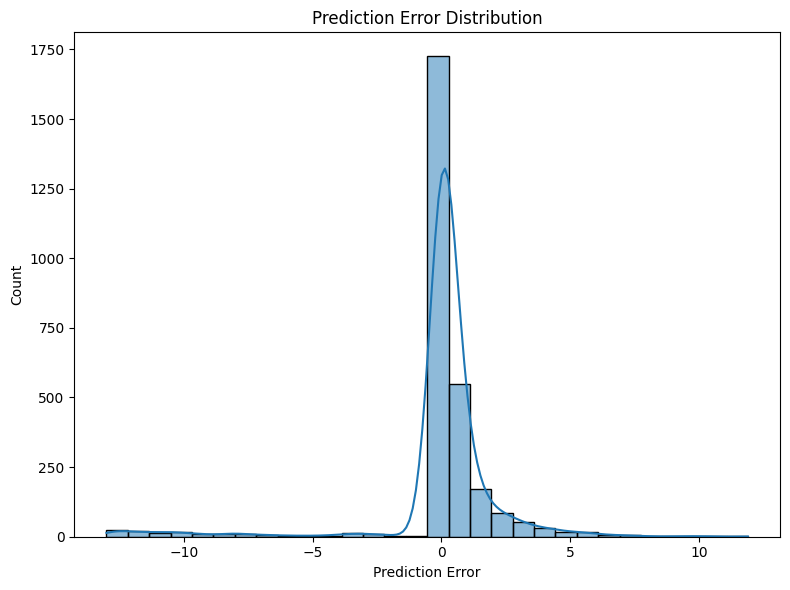

In [30]:
errors = y_test.iloc[:, 0] - y_pred[:, 0]

plt.figure(figsize=(8,6))

sns.histplot(errors, bins=30, kde=True)

plt.title("Prediction Error Distribution")
plt.xlabel("Prediction Error")

plt.tight_layout()
plt.savefig("images/error_distribution.png")
plt.show()

In [31]:
import joblib

joblib.dump(model, "factory_output_prediction_model.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


In [32]:
prediction_df = pd.DataFrame(
    y_pred,
    columns=target_cols
)

prediction_df.to_csv(
    "factory_output_predictions.csv",
    index=False
)

print(prediction_df.head())

   Stage2.Output.Measurement0.U.Actual  Stage2.Output.Measurement1.U.Actual  \
0                             12.69520                               5.4728   
1                             11.74411                               6.4596   
2                             12.82090                               6.4497   
3                             12.79780                               6.7392   
4                              9.75990                               6.5324   

   Stage2.Output.Measurement2.U.Actual  Stage2.Output.Measurement3.U.Actual  \
0                             10.50565                              20.5503   
1                             10.88390                              20.7033   
2                             10.90490                              20.6731   
3                             10.83150                              19.6281   
4                             10.53710                              20.3735   

   Stage2.Output.Measurement4.U.Actual  Stage2.Out

In [33]:
results = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R2 Score"],
    "Value": [mae, mse, rmse, r2]
})

print(results)

     Metric     Value
0       MAE  0.422402
1       MSE  3.320254
2      RMSE  1.822156
3  R2 Score  0.739868
